## IMPORTS

In [1]:
import math
import random
import torch
import matplotlib.pyplot as plt

In [2]:
def set_seed(seed=42):
  random.seed(seed)
  torch.manual_seed(seed)

set_seed(42)
device = "cpu"
if torch.cuda.is_available():
  device = "cuda"

print(device)

cuda


## DATASET GENERATION

We are trying to use protein-inspired structures, so we will try to generate a dataset with helices, sheets and coils.

### Helper functions

The ```normalize``` function converts vectors to unit vectors. Unit vectors help when we want a direction without caring about magnitude like making step directions unit lengtj or keeping coil motion stable. If the vector is extremely small or zero, dividing by its norm would explode or become undefined. So, we clamp the norm from below by ```eps```. ```dim=-1``` helps us work on the $xyz$ coordinates and ```keepdim=True``` keeps that dimension as $1$ instead of removing to help with broadcasting.

In [3]:
def normalize(v, eps=1e-8):
  return v / v.norm(dim=-1, keepdim=True).clamp_min(eps)

The ```rescale_steps_to_bond_length``` function takes a chain of points and forces every consecutive step to have the same length, approximately the desired bond length. It takes the vectors from residue $i$ to residue $i+1$ and normalizes each step and scales it to the bond length and rebuilds the chain. This function helps preserve the local direction pattern of the shape but makes the bond lengths uniform so that the motifs are more backbone-like and easier to compare.

In [4]:
def rescale_steps_to_bond_length(coords, bond_len=1.0):
  steps = coords[1:] - coords[:-1]
  # each row of steps is displacement vector from one residue to next
  steps = normalize(steps) * bond_len
  new_coords = [torch.zeros(3, dtype=coords.dtype, device=coords.device)]
  for s in steps:
    new_coords.append(new_coords[-1]+s)

  return torch.stack(new_coords, dim=0)

The ```random_rotation_matrix``` function creates a random 3D rotation matrix. A valid rotation matrix must have orthonormal columns (columns are perpendicular unit vectors) and must have determinant $+1$. If determinant is $-1$, it includes a reflection. Flipping one column changes determinant to $+1$, giving a proper rotation. We get the orthonormal column matrix through QR decomposition. A protein-like chain should not depend on whether it points up, sideways or diagonaly. This helper function helps us randomly rotate structures for augmentation/visualization.

In [5]:
def random_rotation_matrix(dtype=torch.float32, device="cpu"):
  A = torch.randn(3, 3, dtype=dtype, device=device)
  Q, R = torch.linalg.qr(A)
  if torch.det(Q) < 0:
    Q[:, 0] = -Q[:, 0]

  return Q

The ```apply_random_se3``` function applies a random rigid motion to the chain (SE(3) transform). This function helps with augmentation and is useful because the same chain should still be the same structure after rotation/translation. So this function changes position/orientation in space but preserves distances, angles and shape. In math, rotation is usually defined as $R.x$ where $x$ is column vector but since here coords is a row vector, we use transpose of $R$ to get an equivalent transposed matrix within the same math definition.

In [6]:
def apply_random_se3(coords, rotate=True, translate=True):
  out = coords.clone()
  if rotate == True:
    R = random_rotation_matrix(dtype=out.dtype, device=out.device)
    out = out @ R.T
  if translate == True:
    t = torch.randn(1, 3, dtype=out.dtype, device=out.device)
    out = out + t

  return out

The ```bond_lengths``` function computes the distance between each consecutive pair of points. Mainly used for sanity check.

In [7]:
def bond_lengths(coords):
  return (coords[1:] - coords[:-1]).norm(dim=-1)

The ```plot_chain_3d``` function helps generate a 3D plot.

In [8]:
def plot_chain_3d(coords, title="chain", ax=None):
  c = coords.detach().cpu()
  x, y, z = c[:, 0], c[:, 1], c[:, 2]

  if ax is None:
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection="3d")

  ax.plot(x, y, z, linewidth=2, marker="o", markersize=3)
  ax.scatter(x[0], y[0], z[0], s=60, marker="o", label="start")
  ax.scatter(x[-1], y[-1], z[-1], s=60, marker="^", label="end")
  ax.set_title(title)
  ax.legend()

  eps=1e-3
  xspan = max((x.max()-x.min()).item(), eps)
  yspan = max((y.max()-y.min()).item(), eps)
  zspan = max((z.max()-z.min()).item(), eps)
  ax.set_box_aspect((xspan, yspan, zspan))

  ax.view_init(elev=20, azim=-60)
  # azim = azimuth, horizontal rotation around the plot
  return ax

### Helix generator

A standard 3D helix can be written as
$$r(\theta) = \begin{bmatrix} r\cos\theta \\ r\sin\theta \\ c\theta \end{bmatrix}$$
where $r$ is the radius of the helix, $\theta$ is the angular parameter and $c$ controls how fast the helix rises in $z$ as it turns. So, this traces a spiral around the $z-$axis.

$n_{turn}$ is residues per turn which controls how many discrete points are needed to complete one full $2\pi$ revolution. If $n_{turn}$ is smaller, angle changes faster and helix winds more tightly whereas if it is larger, angle changes more slowly and helix winds more gently. Each step advances the angle by $\frac{2\pi}{n_{turn}}.$

$h$ controls how much the helix moves upward in $z$ when we go from point $i$ to $i+1$. We use ```rescale_steps_to_bond_length``` because the step length though constant, is not necessarily equal to the desired bond length. We do it to ensure that the final chain preserves the local direction pattern of the helix but every step has exactly length $b$.

Also, for $z_i = hi$:
$$\theta_i = \frac{2\pi i}{n_{turn}}$$

$$i = \frac{n_{turn}}{2\pi}\theta_i$$

$$z_i = h \cdot \frac{n_{turn}}{2\pi}\theta_i \equiv c\theta_i$$

In [9]:
def make_helix(
    L,
    radius=1.0,
    rise_per_res=0.6,
    residues_per_turn=3.6,
    bond_len=1.0,
    device="cpu"
):
  i = torch.arange(L, dtype=torch.float32, device=device)
  theta = 2 * math.pi * i / residues_per_turn

  x = radius * torch.cos(theta)
  y = radius * torch.sin(theta)
  z = rise_per_res * i

  coords = torch.stack([x, y, z], dim=-1)
  coords = rescale_steps_to_bond_length(coords, bond_len=bond_len)

  return coords

In [10]:
helix = make_helix(
    L=64,
    radius=2,
    rise_per_res=0.25,
    residues_per_turn=10,
    bond_len=1.0,
    device=device
)

In [11]:
print(helix.shape)

torch.Size([64, 3])


<Axes3D: title={'center': 'Helix'}>

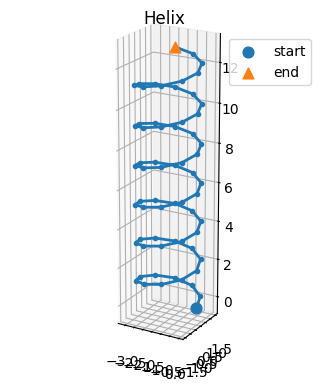

In [12]:
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(131, projection="3d")
plot_chain_3d(helix, "Helix", ax=ax1)

### Strand generator

We move the chain steadily in the $x-$axis i.e. each residue advances by a constant amount in the forward direction. We use the $y$ coordinate to make the chain alternate left-right-left-right to create the zig-zag. The $z$ coordinate helps with the zig-zag above and below the plane ```rescale_steps_to_bond_length``` is once again used to ensure final chain has the same zig-zag directions but every step has the exact bond length.

In [13]:
def make_strand(
    L,
    zigzag_const=1.0,
    z_const=0.5,
    forward_step=0.5,
    bond_len=1.0,
    device="cpu"
):
  i = torch.arange(L, dtype=torch.float32, device=device)

  x = forward_step * i
  y = zigzag_const * ((-1.0) ** i)
  z = z_const * ((-1.0)**(i+1))

  coords = torch.stack([x, y, z], dim=-1)
  coords = rescale_steps_to_bond_length(coords, bond_len=bond_len)

  return coords

In [14]:
strand = make_strand(
    L = 64,
    bond_len=1.0,
    device=device
)

In [15]:
print(strand.shape)

torch.Size([64, 3])


<Axes3D: title={'center': 'Strand'}>

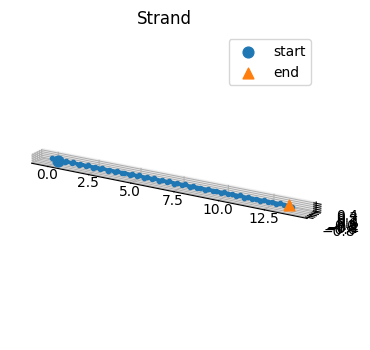

In [16]:
fig = plt.figure(figsize=(15,4))
ax2 = fig.add_subplot(132, projection="3d")
plot_chain_3d(strand, "Strand", ax=ax2)

### Coil generator

A coil here is a stochastic chain, each new bond direction is a small random perturbation of the previous one. First point is placed at the origin and then we sample a random initial direction using gaussian and generate a corresponding random unit vector. Then at each step, sample Gaussian noise, scale it by ```turn_strength``` and add it to the current direction and normalize it to the get the unit vector in the new direction. Now, just move one bond length in that direction.

A helix is determined and structured whereas coil is stochastic and irregular.

In [17]:
def make_coil(
    L,
    turn_strength=0.35,
    bond_len=1.0,
    device="cpu"
):
  coords = [torch.zeros(3, dtype=torch.float32, device=device)]
  direction = torch.randn(3, device=device)
  direction = direction / direction.norm()

  for _ in range(L-1):
    noise = turn_strength * torch.randn(3, device=device)
    direction = direction + noise
    direction = direction / direction.norm()
    next_pt = coords[-1] + bond_len * direction
    coords.append(next_pt)

  return torch.stack(coords, dim=0)

In [18]:
coil = make_coil(
    L=64,
    bond_len=1.0,
    device=device
)

In [19]:
print(coil.shape)

torch.Size([64, 3])


<Axes3D: title={'center': 'Coil'}>

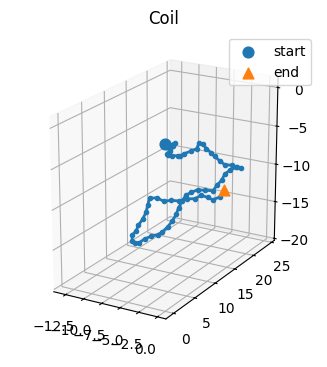

In [20]:
fig = plt.figure(figsize=(15, 4))
ax3 = fig.add_subplot(133, projection="3d")
plot_chain_3d(coil, "Coil", ax=ax3)

### SE(3) test

Checking that the object is a 3D shape and not tied to one absolute orientation.

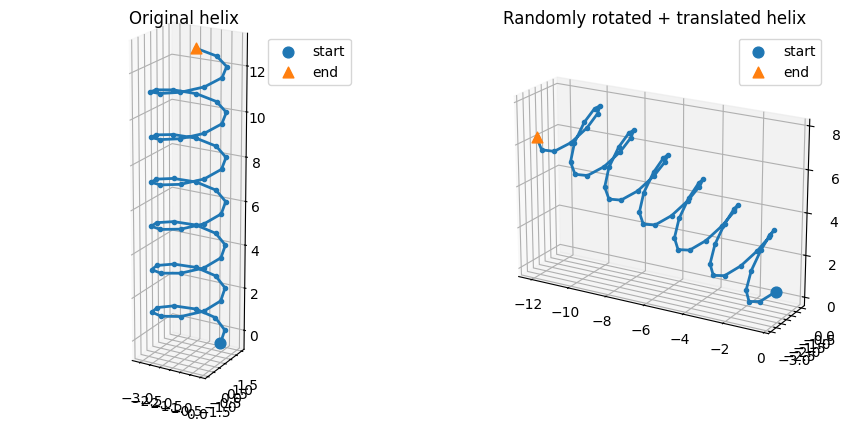

In [22]:
helix_augmentation = apply_random_se3(helix)
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(121, projection="3d")
plot_chain_3d(helix, "Original helix", ax=ax1)

ax2 = fig.add_subplot(122, projection="3d")
plot_chain_3d(helix_augmentation, "Randomly rotated + translated helix", ax=ax2)

plt.tight_layout()
plt.show()

### Motif wrapper function

In [24]:
MOTIF_TO_ID = {"helix": 0, "strand": 1, "coil": 2}
ID_TO_MOTIF = {0: "helix", 1: "strand", 2: "coil"}

def generate_motif(kind, L, bond_len=1.0, device="cpu", **kwargs):
  if kind == "helix":
    return make_helix(L=L, bond_len=bond_len, device=device, **kwargs)
  elif kind == "strand":
    return make_strand(L=L, bond_len=bond_len, device=device, **kwargs)
  elif kind == "coil":
    return make_coil(L=L, bond_len=bond_len, device=device, **kwargs)
  else:
    raise ValueError(f"Unknown motif kind: {kind}")

### Stitch segments

Stitching multiple motifs together to form one protein chain. Seam point is the point where two motifs are stitched together. In other words, the end point of the previous motif must be the same as the start point of the current motif. So, for all motifs except for the first one we need one extra anchor point so that after dropping the duplicated seam point, they still contribute the same number of residues. We can add random rotation to each motif to ensure that all the motifs are not in the same canonical orientation. We first shift each segment so that its start point is the origin and if the segment is not the first segment then we place it at the last point of the previous segment.

In [34]:
def stitch_segments(specs, bond_len=1.0, random_orient=True, device="cpu"):
  coords_parts = []
  label_parts = []
  segid_parts = []

  prev_end = None

  for seg_id, spec in enumerate(specs):
    kind = spec["kind"]
    contrib_len = spec["length"]
    kwargs = spec.get("kwargs", {})

    raw_len = 0
    if seg_id == 0:
      raw_len = contrib_len
    else:
      raw_len = contrib_len + 1

    seg = generate_motif(
        kind=kind,
        L=raw_len,
        bond_len=bond_len,
        device=device,
        **kwargs
    )

    if random_orient:
      R = random_rotation_matrix(dtype=seg.dtype, device=seg.device)
      seg = seg @ R.T

    seg = seg - seg[0:1]

    if seg_id == 0:
      placed = seg
    else:
      seg = seg + prev_end.unsqueeze(0)
      # .unsqueeze(0) adds a dimension of size 1 at position 0
      # so that i can broadcast when added to seg of shape (L, 3)
      placed = seg[1:]

    coords_parts.append(placed)
    label_parts.append(torch.full((placed.shape[0],), MOTIF_TO_ID[kind], dtype=torch.long, device=device))
    segid_parts.append(torch.full((placed.shape[0],), seg_id, dtype=torch.long, device=device))

    prev_end = placed[-1]

  coords = torch.cat(coords_parts, dim=0)
  labels = torch.cat(label_parts, dim=0) # motif id per residue
  seg_ids = torch.cat(segid_parts, dim=0) # segment id per residue

  return coords, labels, seg_ids

### Chain plotting helper

In [67]:
def plot_3d_chain(coords, labels, title="composed chain", ax=None):
  coords = coords.detach().cpu()
  labels = labels.detach().cpu()

  x = coords[:, 0]
  y = coords[:, 1]
  z = coords[:, 2]

  if ax is None:
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")

  ax.plot(x, y, z, color="black", linewidth=1.0, alpha=0.7)

  colors = {
      0: "tab:blue", #helix
      1: "tab:orange", #strand
      2: "tab:green", #coil
  }
  #tab: ---> from tableau color palette looks nice

  for motif_id, motif_name in ID_TO_MOTIF.items():
    mask = (labels == motif_id)
    # creates boolean tensor where values are true wherever
    # residue type is motif type
    if mask.any(): # checks if any residues are of that type, otherwise skips
      ax.scatter(
          x[mask],
          y[mask],
          z[mask],
          s=14,
          color=colors[motif_id],
          label=motif_name
      )

      # x[mask], y[mask], z[mask] adds only coordinates where
      # mask is true

  ax.scatter(x[0], y[0], z[0], s=60, marker="o", color="red", label="start")
  ax.scatter(x[-1], y[-1], z[-1], s=60, marker="^", color="purple", label="end")

  ax.set_title(title)
  ax.legend()

  eps=1e-3
  xspan = max((x.max() - x.min()).item(), eps)
  yspan = max((y.max() - y.min()).item(), eps)
  zspan = max((z.max() - z.min()).item(), eps)
  ax.set_box_aspect((xspan, yspan, zspan))
  ax.view_init(elev=20, azim=-60)

  return ax


#### testing with a L=64 fixed chain

In [62]:
specs = [
    {
        "kind": "helix",
        "length": 20,
        "kwargs": {
            "radius": 1.0,
            "rise_per_res": 0.25,
            "residues_per_turn": 5
        },
    },
    {
        "kind": "strand",
        "length": 20,
        "kwargs": {
            "zigzag_const": 1.0,
            "z_const": 0.5,
            "forward_step": 0.5
        },
    },
    {
        "kind": "coil",
        "length": 24,
        "kwargs": {
            "turn_strength": 0.35
        },
    },
]

coords, labels, seg_ids = stitch_segments(
    specs,
    bond_len=1.0,
    random_orient=True,
    device=device
)

In [63]:
print(coords.shape)

torch.Size([64, 3])


In [64]:
print(labels.shape)

torch.Size([64])


In [65]:
print(seg_ids.shape)

torch.Size([64])


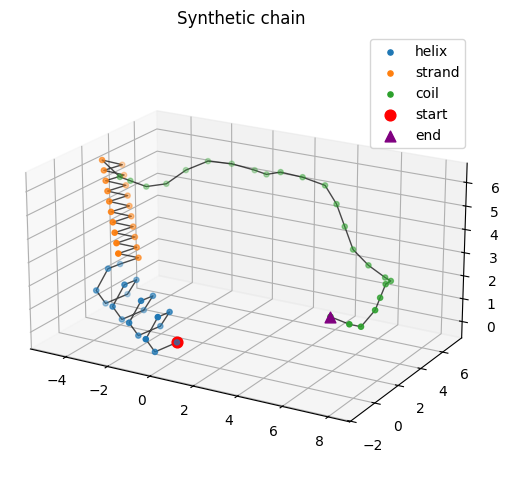

In [66]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
_ = plot_3d_chain(coords, labels, title="Synthetic chain", ax=ax)
plt.show()

### FULL CHAIN GENERATOR

The ```sample_segment_lengths``` function returns a list of ```n_segments``` positive lengths that sum exactly to a given total length with each length lying in a range of min length and max length.

In [75]:
def sample_segment_lengths(
    total_len,
    n_segments,
    min_len=12,
    max_len=24
):
  if total_len < n_segments * min_len:
    raise ValueError("total_len too small for chosen n_segments and min_len")
  if total_len > n_segments * max_len:
    raise ValueError("total_len too large for chosen n_segments and max_len")

  lengths = [min_len] * n_segments
  remaining = total_len - (n_segments * min_len)
  capacities = [max_len - min_len] * n_segments

  while remaining > 0:
    valid_idxs = [i for i in range(n_segments) if capacities[i]>0]
    j = random.choice(valid_idxs)
    lengths[j] += 1
    capacities[j] -= 1
    remaining -= 1

  return lengths

The ```sample_motif_kinds``` returns a list of ```n_segments``` motif kinds.

In [71]:
def sample_motif_kinds(n_segments, motif_names=("helix", "strand", "coil")):
  kinds = []
  prev = None # avoiding consecutive duplicate motif types for now

  for _ in range(n_segments):
    choices = [m for m in motif_names if m!=prev]
    kind = random.choice(choices)
    kinds.append(kind)
    prev = kind

  return kinds

The ```sample_motif_kwargs``` function generates the kwargs for each ```make_<shape>``` function randomly.

In [72]:
def sample_motif_kwargs(kind):
  if kind == "helix":
    return {
        "radius": random.uniform(1.5, 2.2),
        "rise_per_res": random.uniform(0.20, 0.35),
        "residues_per_turn": random.uniform(8.0, 12.0)
    }
  elif kind == "strand":
    return {
        "zigzag_const": random.uniform(0.8, 1.2),
        "z_const": random.uniform(0.3, 0.7),
        "forward_step": random.uniform(0.4, 0.7)
    }
  elif kind == "coil":
    return {
        "turn_strength": random.uniform(0.20, 0.45)
    }
  else:
    raise ValueError(f"Unknown motif kind: {kind}")

The ```sample_random_specs``` function combines all the random functions to build a random valid spec list.

In [73]:
def sample_random_specs(
    total_len=64,
    min_segments=3,
    max_segments=5,
    min_len=12,
    max_len=24
):
  feasible_segment_counts = []
  for n in range(min_segments, max_segments+1):
    if n*min_len <= total_len and total_len <= n*max_len:
      feasible_segment_counts.append(n)

  if not feasible_segment_counts:
    raise ValueError("No feasible number of segments for these constraints")

  n_segments = random.choice(feasible_segment_counts)
  lengths = sample_segment_lengths(
      total_len=total_len,
      n_segments=n_segments,
      min_len=min_len,
      max_len=max_len
  )
  kinds = sample_motif_kinds(n_segments)

  specs = []
  for kind, length in zip(kinds, lengths):
    specs.append({
        "kind": kind,
        "length": length,
        "kwargs": sample_motif_kwargs(kind),
    })

  return specs

In [83]:
specs = sample_random_specs(
    total_len=64,
    min_segments=3,
    max_segments=5,
    min_len=12,
    max_len=24
)

print("Random specs:")
for s in specs:
  print(s["kind"], s["length"], s["kwargs"])

print("Total length:", sum(s["length"] for s in specs))

Random specs:
strand 19 {'zigzag_const': 0.9480723868467531, 'z_const': 0.38380281230859503, 'forward_step': 0.480093346614734}
coil 15 {'turn_strength': 0.4341636469281235}
strand 15 {'zigzag_const': 1.0592141540986373, 'z_const': 0.5436524022667952, 'forward_step': 0.4513415944594291}
helix 15 {'radius': 2.0103887585652447, 'rise_per_res': 0.22451037406428925, 'residues_per_turn': 9.517821767030592}
Total length: 64


In [84]:
coords, labels, seg_ids = stitch_segments(
    specs,
    bond_len=1.0,
    random_orient=True,
    device=device
)

In [85]:
print(coords.shape)

torch.Size([64, 3])


In [86]:
print(labels.shape)

torch.Size([64])


In [87]:
print(seg_ids.shape)

torch.Size([64])


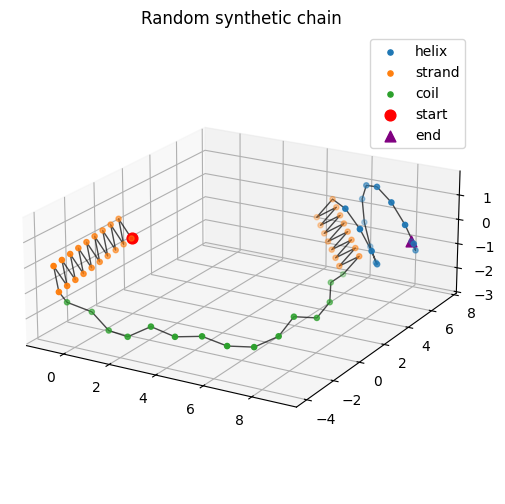

In [88]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
_ = plot_3d_chain(coords, labels, title="Random synthetic chain", ax=ax)
plt.show()